Prompt template

In [7]:
from langchain_core.prompts import ChatPromptTemplate, HumanMessagePromptTemplate, PromptTemplate
from langchain import hub

In [8]:
RAG_PROMPT_TEMPLATE = """You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:"""

prompt = ChatPromptTemplate(
    input_variables=["context", "question"],
    messages=[
        HumanMessagePromptTemplate(
            prompt=PromptTemplate(
                input_variables=["context", "question"],
                template=RAG_PROMPT_TEMPLATE,
            )
        )
    ]
)

prompt


### or 

# prompt = hub.pull('rlm/rag-prompt') ## REF: https://smith.langchain.com/hub
# prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

## Create RAG AGENT

In [9]:
from typing_extensions import Annotated, TypedDict, List
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langchain_core.documents import Document
from langchain.chat_models import init_chat_model

In [10]:
llm = init_chat_model(model='gpt-4.1-nano', model_provider="openai")

In [11]:
llm.invoke("Hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_1f35c1788c', 'id': 'chatcmpl-CPBG9llx4hV8afedCZXMBz17Dnkj5', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--ff9276ec-9bd7-4c70-a2ab-187d1ee1b469-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [12]:
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

In [13]:
def retrieve(state:State):
    retrived_docs = vector_store_local.similarity_search(state['question'], k=4)
    return {'context': retrived_docs}

In [14]:
def generator(state: State):
    docs_content = "\n\n".join(doc.page_content  for doc in state['context'])
    messages = prompt.invoke({'question': state['question'], 'context': docs_content})
    responce = llm.invoke(messages)
    return {'answer': responce.content}

In [15]:
graph_builder = StateGraph(State)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generator", generator)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generator")
graph_builder.add_edge("generator", END)

graph = graph_builder.compile()

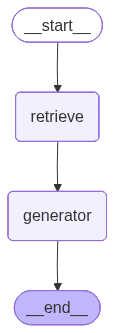

In [16]:
graph

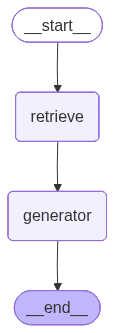

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
print(graph.get_graph().draw_mermaid()) ## REF: https://mermaid.live/

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	retrieve(retrieve)
	generator(generator)
	__end__([<p>__end__</p>]):::last
	__start__ --> retrieve;
	retrieve --> generator;
	generator --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [19]:
graph.invoke({'question': 'What is Short-term memory'})

{'question': 'What is Short-term memory',
 'context': [Document(id='832b4a01-4f2d-462b-8a4c-12751984a029', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'start_index': 10685}, page_content='Short-Term Memory (STM) or Working Memory: It stores information that we are currently aware of and needed to carry out complex cognitive tasks such as learning and reasoning. Short-term memory is believed to have the capacity of about 7 items (Miller 1956) and lasts for 20-30 seconds.\n\n\nLong-Term Memory (LTM): Long-term memory can store information for a remarkably long time, ranging from a few days to decades, with an essentially unlimited storage capacity. There are two subtypes of LTM:\n\nExplicit / declarative memory: This is memory of facts and events, and refers to those memories that can be consciously recalled, including episodic memory (events and experiences) and semantic memory (facts and concepts).\nImplicit / procedural memory: This type of memory is un

In [ ]:
graph.invoke({'question':'What is Indian AI Production?'})

{'question': 'What is Indian AI Production?',
 'context': [Document(id='7725e059-826e-407f-bb7a-1ce8c9783cc3', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'start_index': 26585}, page_content='The generative agent architecture. (Image source: Park et al. 2023)\n\nThis fun simulation results in emergent social behavior, such as information diffusion, relationship memory (e.g. two agents continuing the conversation topic) and coordination of social events (e.g. host a party and invite many others).\nProof-of-Concept Examples#\nAutoGPT has drawn a lot of attention into the possibility of setting up autonomous agents with LLM as the main controller. It has quite a lot of reliability issues given the natural language interface, but nevertheless a cool proof-of-concept demo. A lot of code in AutoGPT is about format parsing.\nHere is the system message used by AutoGPT, where {{...}} are user inputs:\nYou are {{ai-name}}, {{user-provided AI bot description}}.\nYo